<a href="https://colab.research.google.com/github/alnafee-s/heart-disease/blob/main/Welcome_to_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Upload heart.csv file...


Saving heart.csv to heart (2).csv
Dataset loaded successfully!
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  target  
0   2     3       0  
1   0     3       0  
2   0     3       0  
3   1     3       0  
4   3     2       0  

Decision Tree (ID3-like) Accuracy: 0.9853658536585366

Decision Tree Visualization:


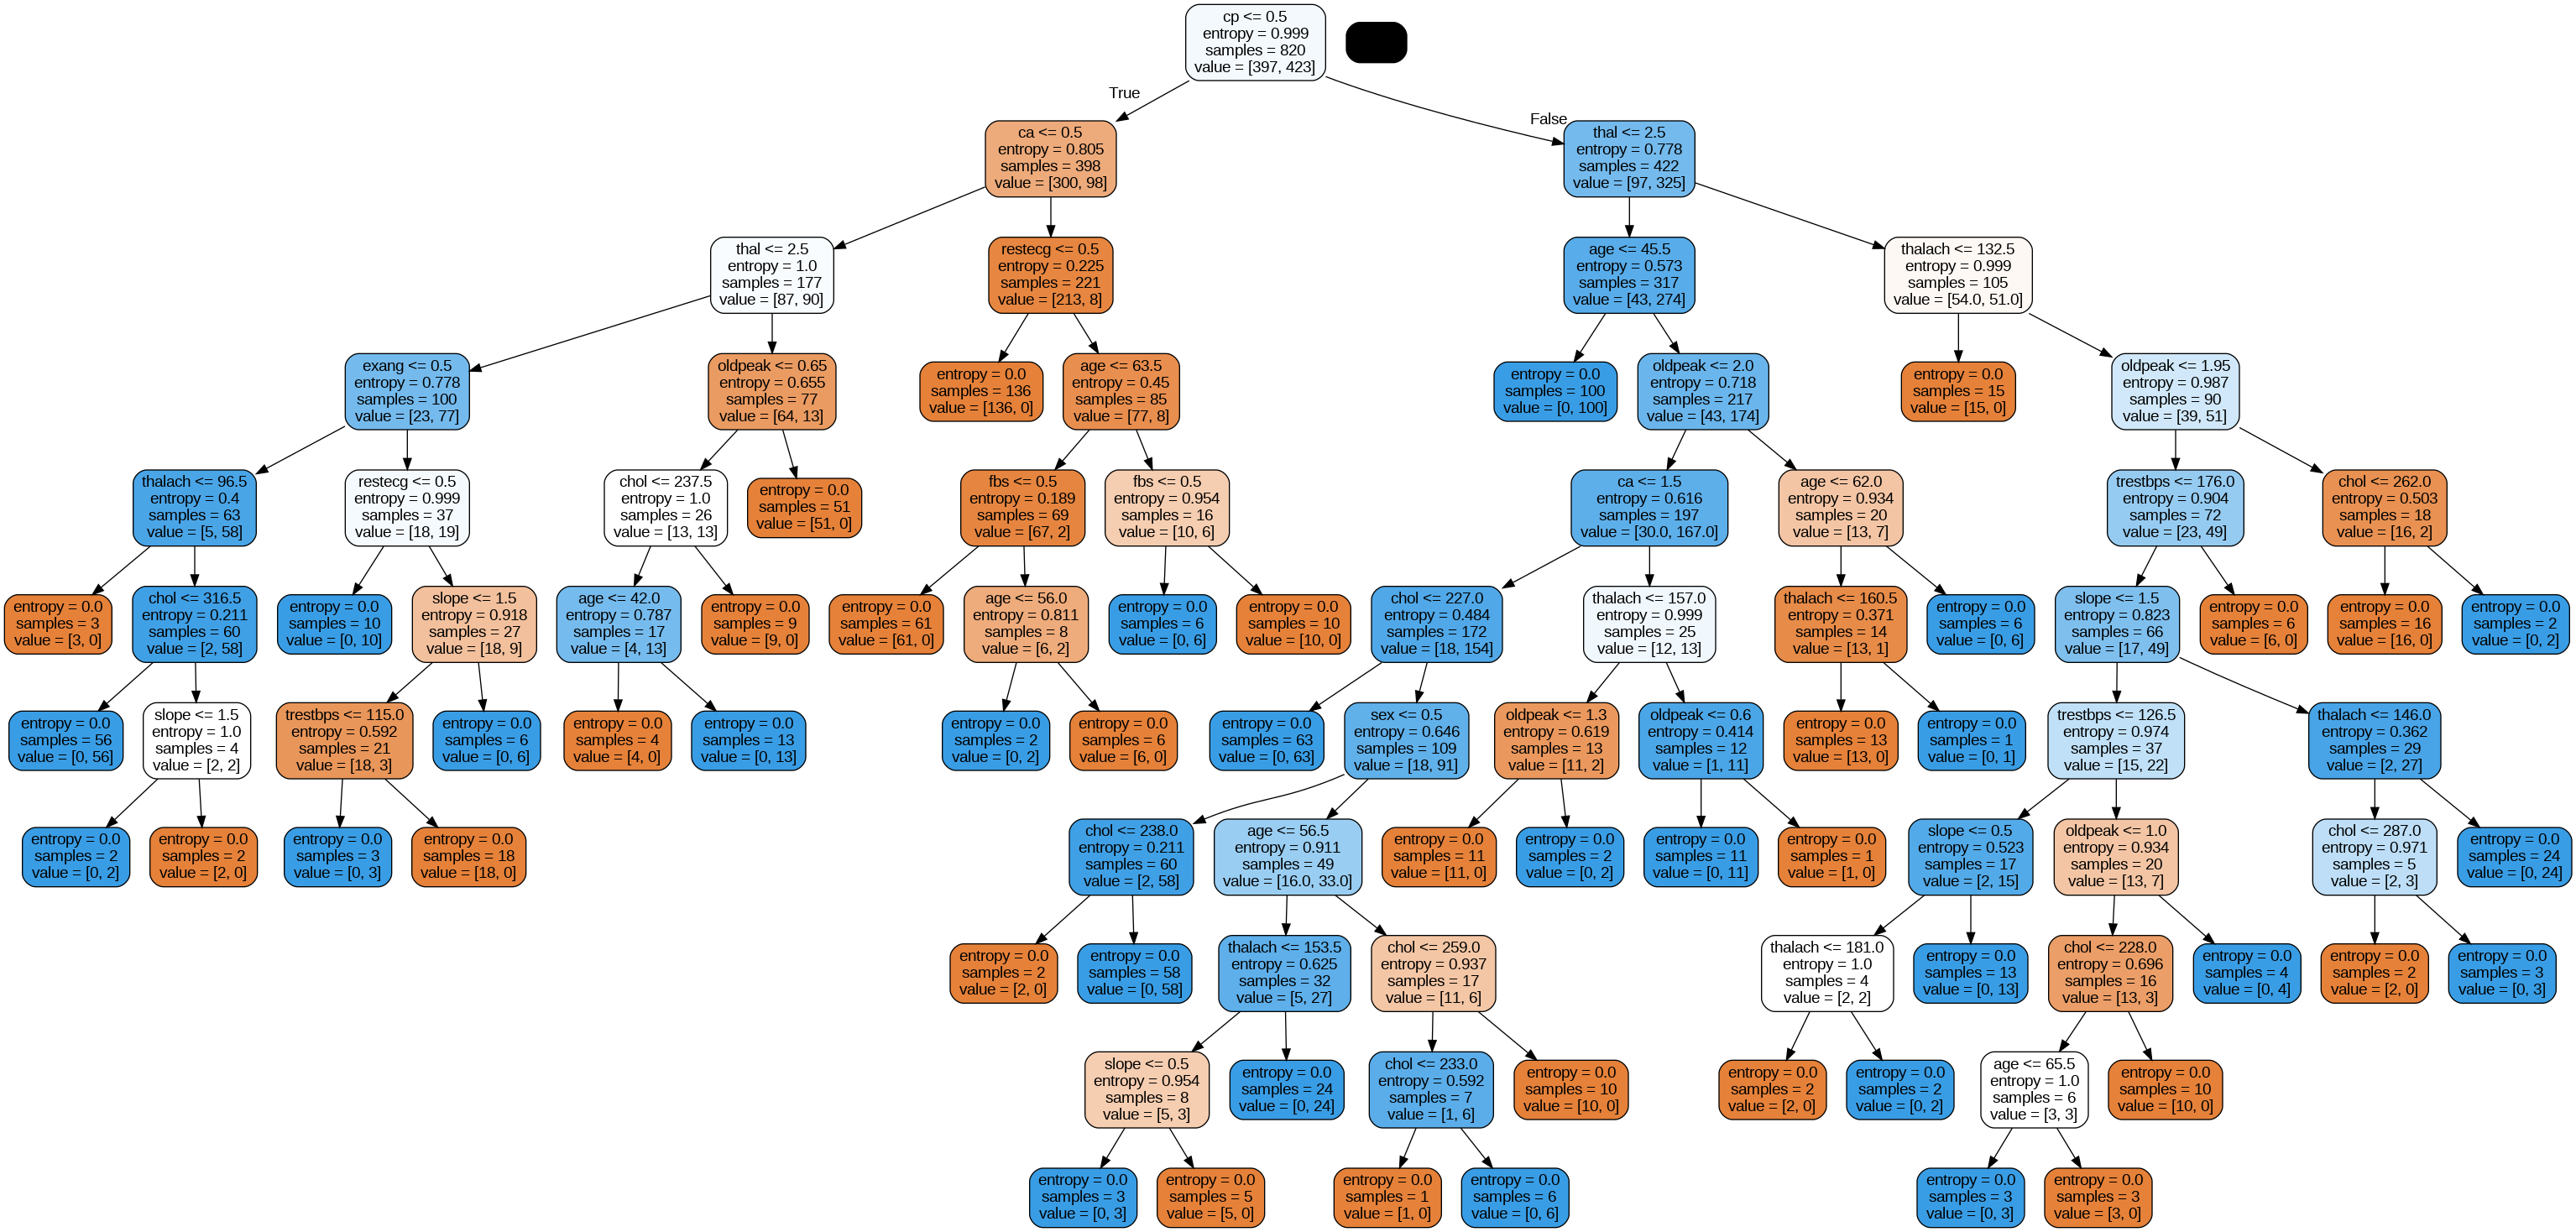

In [4]:
import pandas as pd
from google.colab import files
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from IPython.display import Image, display
import pydotplus

# Upload dataset
print("Upload heart.csv file...")
uploaded = files.upload()

# Load dataset
data = pd.read_csv("heart.csv")
print("Dataset loaded successfully!")
print(data.head())

# Split into features and target
X = data.drop("target", axis=1)
y = data["target"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train ID3-like model using scikit-learn's DecisionTreeClassifier
# Using criterion='entropy' mimics the ID3 algorithm.
model = DecisionTreeClassifier(criterion='entropy', random_state=42)
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("\nDecision Tree (ID3-like) Accuracy:", accuracy)

# Save and show the tree
feature_names = X.columns.tolist()
dot_data = export_graphviz(model, out_file=None,
                           feature_names=feature_names,
                           filled=True, rounded=True)

# Convert DOT to PNG
graph = pydotplus.graph_from_dot_data(dot_data)
graph.write_png("id3_tree.png")

print("\nDecision Tree Visualization:")
display(Image("id3_tree.png"))
